
Running experiment for K=1...
Confusion Matrix:
[[469. 266.]
 [276. 458.]]
Accuracy: 0.6310
Precision: 0.6311
Recall: 0.6310
F1-Score: 0.6310


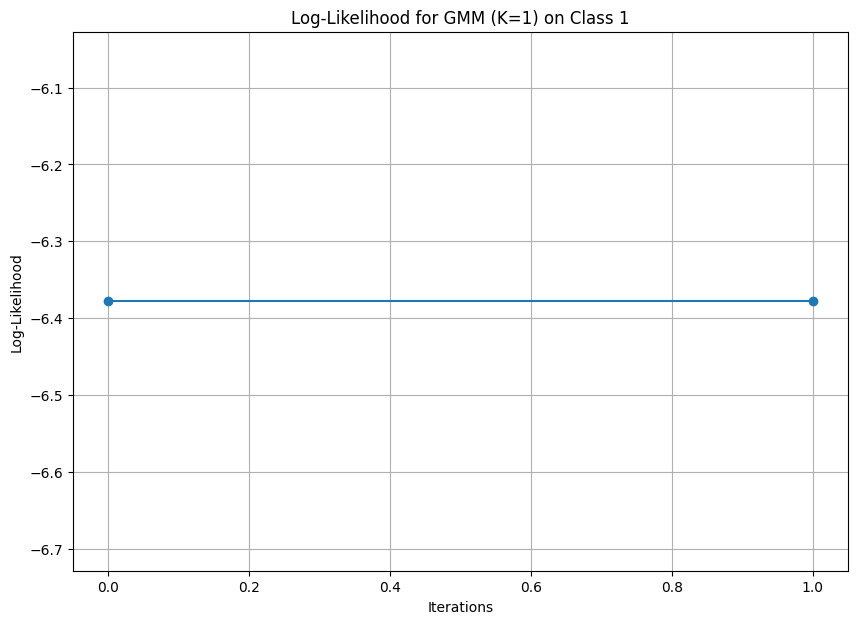

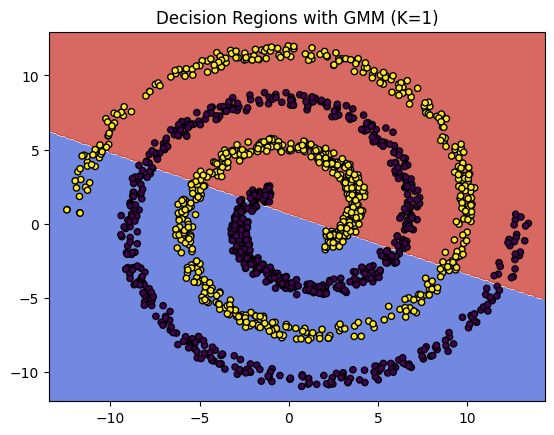


Running experiment for K=2...
Confusion Matrix:
[[542. 193.]
 [218. 516.]]
Accuracy: 0.7202
Precision: 0.7205
Recall: 0.7202
F1-Score: 0.7201


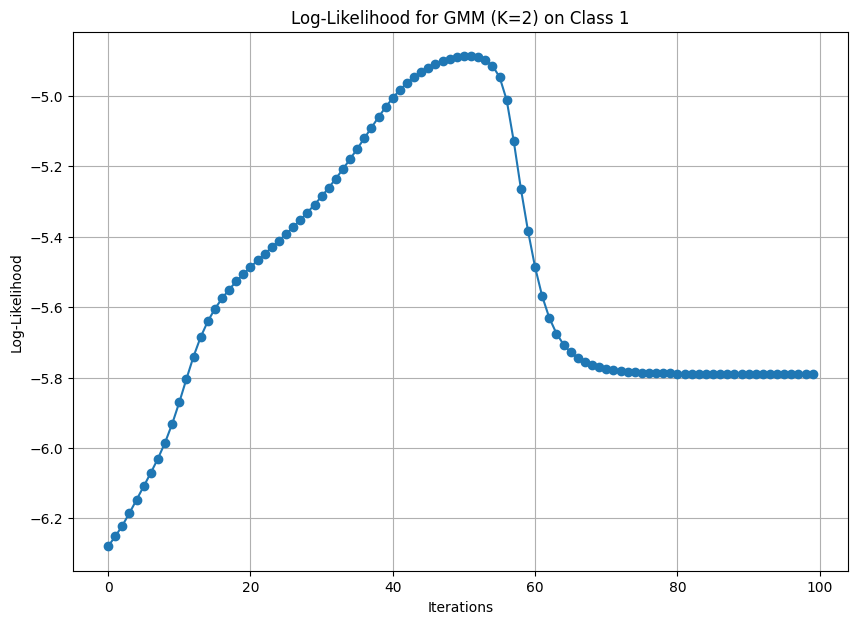

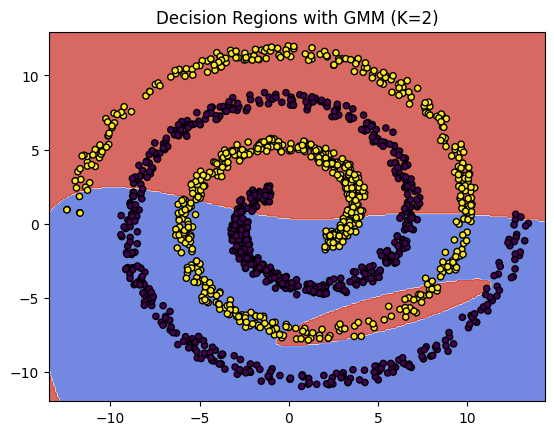


Running experiment for K=4...
Confusion Matrix:
[[603. 132.]
 [151. 583.]]
Accuracy: 0.8074
Precision: 0.8076
Recall: 0.8073
F1-Score: 0.8073


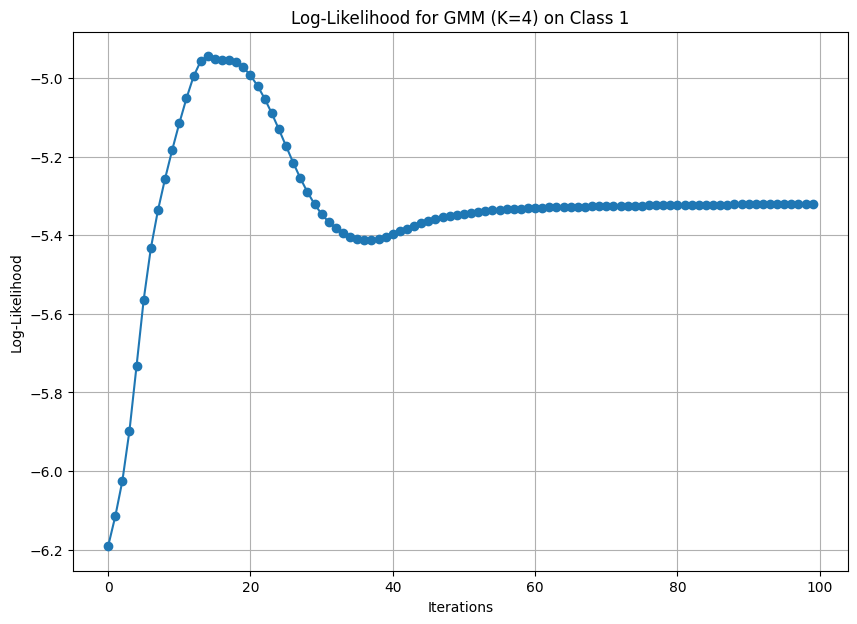

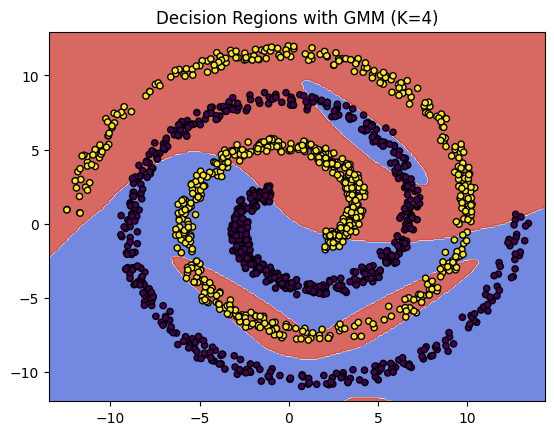


Running experiment for K=8...
Confusion Matrix:
[[713.  22.]
 [  5. 729.]]
Accuracy: 0.9816
Precision: 0.9819
Recall: 0.9816
F1-Score: 0.9816


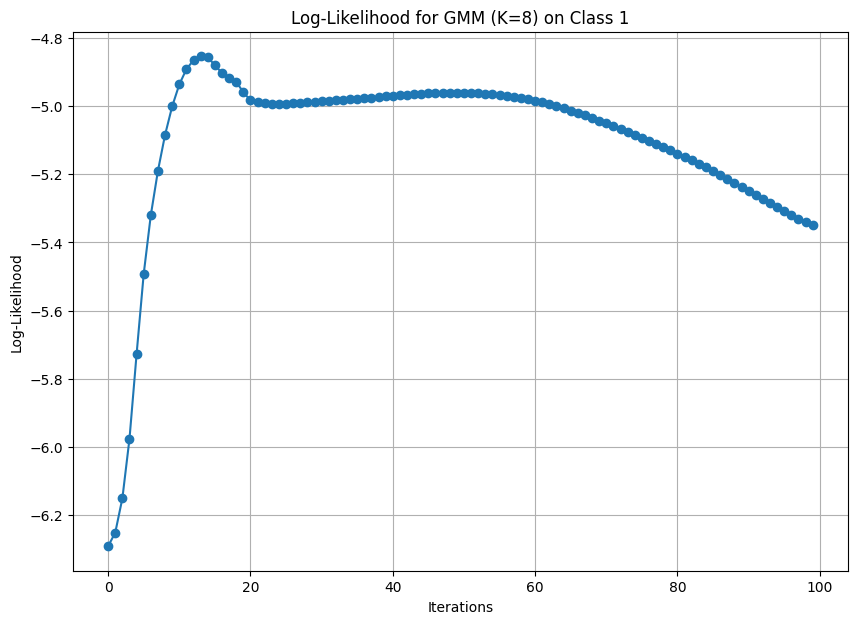

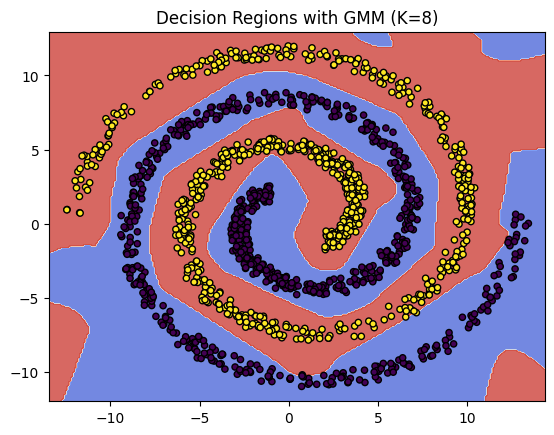


Running experiment for K=16...
Confusion Matrix:
[[735.   0.]
 [  0. 734.]]
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


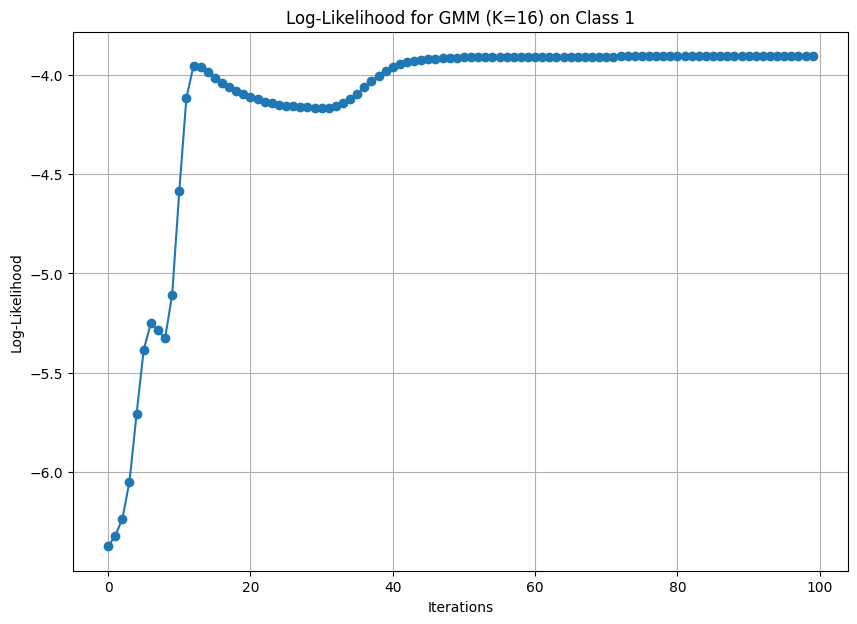

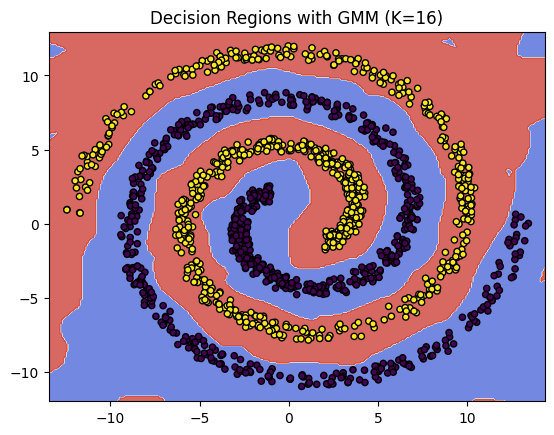


Running experiment for K=32...


C:\Users\alpine\AppData\Local\Temp\ipykernel_29952\359605571.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (1. / (np.sqrt((2 * np.pi)**d * np.linalg.det(cov)))) * \


LinAlgError: Singular matrix

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Function to split data into training and test sets (70% training, 30% test)
def train_test_split(class1_data, class2_data, test_size=0.3):
    n1, n2 = len(class1_data), len(class2_data)
    idx1 = np.random.permutation(n1)
    idx2 = np.random.permutation(n2)
    
    split1 = int(n1 * (1 - test_size))
    split2 = int(n2 * (1 - test_size))
    
    train1, test1 = class1_data[idx1[:split1]], class1_data[idx1[split1:]]
    train2, test2 = class2_data[idx2[:split2]], class2_data[idx2[split2:]]
    
    return train1, test1, train2, test2

# Function to perform K-Means clustering
def kmeans(X, k, max_iters=100):
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    for _ in range(max_iters):
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        clusters = np.argmin(distances, axis=1)
        new_centroids = np.array([X[clusters == i].mean(axis=0) for i in range(k)])
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    return centroids, clusters

# Gaussian PDF function
def gaussian_pdf(x, mean, cov):
    d = len(mean)
    x_m = x - mean
    return (1. / (np.sqrt((2 * np.pi)**d * np.linalg.det(cov)))) * \
           np.exp(-0.5 * np.dot(np.dot(x_m.T, np.linalg.inv(cov)), x_m))

# Function to perform GMM with EM algorithm
def gmm(X, k, max_iters=100, tol=1e-6, init_means=None, init_covariances=None, init_weights=None):
    n, d = X.shape
    # Initialize parameters using K-Means
    if init_means is None:
        init_means = X[np.random.choice(X.shape[0], k, replace=False)]
    if init_covariances is None:
        init_covariances = np.array([np.cov(X.T) for _ in range(k)])
    if init_weights is None:
        init_weights = np.ones(k) / k
        
    means = init_means
    covariances = init_covariances
    weights = init_weights
    log_likelihoods = []

    for _ in range(max_iters):
        # E-Step: Calculate responsibilities
        responsibilities = np.zeros((n, k))
        for i in range(k):
            for j in range(n):
                responsibilities[j, i] = weights[i] * gaussian_pdf(X[j], means[i], covariances[i])
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        # M-Step: Update parameters
        N_k = responsibilities.sum(axis=0)
        weights = N_k / n
        means = np.dot(responsibilities.T, X) / N_k[:, np.newaxis]
        covariances = np.array([np.dot((responsibilities[:, i][:, np.newaxis] * (X - means[i])).T, (X - means[i])) / N_k[i]
                                for i in range(k)])

        # Compute log-likelihood
        log_likelihood = np.sum(np.log(np.sum([weights[i] * gaussian_pdf(X[j], means[i], covariances[i]) 
                                               for i in range(k)], axis=0)))
        log_likelihoods.append(log_likelihood)

        # Check for convergence
        if len(log_likelihoods) > 1 and np.abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break

    return means, covariances, weights, responsibilities, log_likelihoods

# Bayes Classifier using GMMs
def bayes_classifier_gmm(train1, train2, test_data, k):
    # Train GMMs for each class
    means1, covariances1, weights1, _, _ = gmm(train1, k)
    means2, covariances2, weights2, _, _ = gmm(train2, k)
    
    # Classify test data
    predictions = []
    for x in test_data:
        prob1 = np.sum([weights1[i] * gaussian_pdf(x, means1[i], covariances1[i]) for i in range(k)])
        prob2 = np.sum([weights2[i] * gaussian_pdf(x, means2[i], covariances2[i]) for i in range(k)])
        predictions.append(0 if prob1 > prob2 else 1)
    return np.array(predictions)

# Function to evaluate performance (Precision, Recall, F1, Confusion Matrix)
def evaluate_performance(y_true, y_pred):
    n_classes = len(np.unique(y_true))
    cm = np.zeros((n_classes, n_classes))
    
    for i in range(len(y_true)):
        cm[int(y_true[i]), int(y_pred[i])] += 1
    
    accuracy = np.trace(cm) / np.sum(cm)
    precision = np.diag(cm) / np.sum(cm, axis=0)
    recall = np.diag(cm) / np.sum(cm, axis=1)
    f1 = 2 * precision * recall / (precision + recall)
    
    print(f"Confusion Matrix:\n{cm}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {np.nanmean(precision):.4f}")
    print(f"Recall: {np.nanmean(recall):.4f}")
    print(f"F1-Score: {np.nanmean(f1):.4f}")
    
    return cm, accuracy, precision, recall, f1

# Plotting functions for decision boundaries, contours, and log-likelihoods
def plot_log_likelihoods(log_likelihoods, title):
    plt.figure(figsize=(10, 7))
    plt.plot(log_likelihoods, marker='o')
    plt.title(title)
    plt.xlabel('Iterations')
    plt.ylabel('Log-Likelihood')
    plt.grid(True)
    plt.show()

# Function to plot decision regions and training data
def plot_decision_regions(X, y, gmm1, gmm2, k):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    
    Z = bayes_classifier_gmm(gmm1, gmm2, np.c_[xx.ravel(), yy.ravel()], k)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=20)
    plt.title(f'Decision Regions with GMM (K={k})')
    plt.show()

# Main execution
with open('NLS_Group03.txt', 'r') as f:
    lines = f.readlines()

lines = lines[1:]  # Assuming the first line is a header
class1_data = []
class2_data = []

for i, line in enumerate(lines):
    if i <= 2446:  # Class 1
        class1_data.append(line.strip().split())
    else:  # Class 2
        class2_data.append(line.strip().split())

# Convert to NumPy arrays
class1_data = np.array(class1_data, dtype=float)
class2_data = np.array(class2_data, dtype=float)

# Split data into training and test sets (70% training, 30% test)
train1, test1, train2, test2 = train_test_split(class1_data, class2_data)

# Run experiments with different numbers of mixtures for GMM
K_values = [1, 2, 4, 8, 16, 32, 64]
for k in K_values:
    print(f"\nRunning experiment for K={k}...")
    
    # Run Bayes Classifier using GMM for classification
    test_data = np.vstack((test1, test2))
    y_true = np.array([0] * len(test1) + [1] * len(test2))
    y_pred = bayes_classifier_gmm(train1, train2, test_data, k)
    
    # Evaluate performance
    cm, accuracy, precision, recall, f1 = evaluate_performance(y_true, y_pred)
    
    # Plot log-likelihood for GMM training (example for train1 GMM)
    _, _, _, _, log_likelihoods = gmm(train1, k)
    plot_log_likelihoods(log_likelihoods, f'Log-Likelihood for GMM (K={k}) on Class 1')
    
    # Plot decision regions (requires GMMs trained for both classes)
    plot_decision_regions(test_data, y_true, train1, train2, k)


Data Splitting: train_test_split splits the data into 70% training and 30% test sets.
GMM Initialization: K-Means is used to initialize GMM parameters (means, covariances, and weights).
Bayes Classifier: The classifier trains a GMM for each class and classifies test points based on posterior probabilities.
Evaluation: After classification, precision, recall, and F1-score are computed along with the confusion matrix.
Plots:
Log-Likelihood Plot: Plots how log-likelihood changes during GMM training.
Decision Region Plot: Shows decision boundaries based on GMM classifiers.